<a href="https://colab.research.google.com/github/AxelYoel/FlyRank-AI-Internship---Axel-Yoel-Chandra/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelYoel/FlyRank-AI-Internship---Axel-Yoel-Chandra/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [8]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [9]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queu

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [10]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [11]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [17]:
df['impressions_90d']

,impressions_90d
0,3803
1,15320
2,12581
3,11751
4,19140
...,...
29995,1
29996,761
29997,6336
29998,154763


### Discovery A — "High search volume means more traffic." Does it?

In [12]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


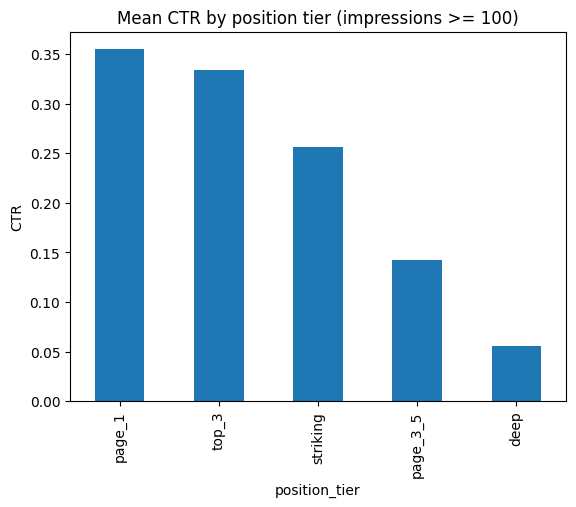

In [13]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [14]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [24]:
# Discovery A for impressions_90d > 0
filtered_impression = df[df['impressions_90d']>0]
corr = filtered_impression["search_volume"].corr(filtered_impression["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d > 0 : {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")
print("High search volume does not reliably translate to high impressions, and low search volume does not necessarily limit impression volume.")

Correlation between search_volume and impressions_90d > 0 : 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.
High search volume does not reliably translate to high impressions, and low search volume does not necessarily limit impression volume.


   position_tier        content_type       ctr
12          deep      feedly article  0.044000
9         page_1  comparison article  0.141239
10      page_3_5  comparison article  0.093968
7       striking  comparison article  0.147368
13         top_3  comparison article  0.000000


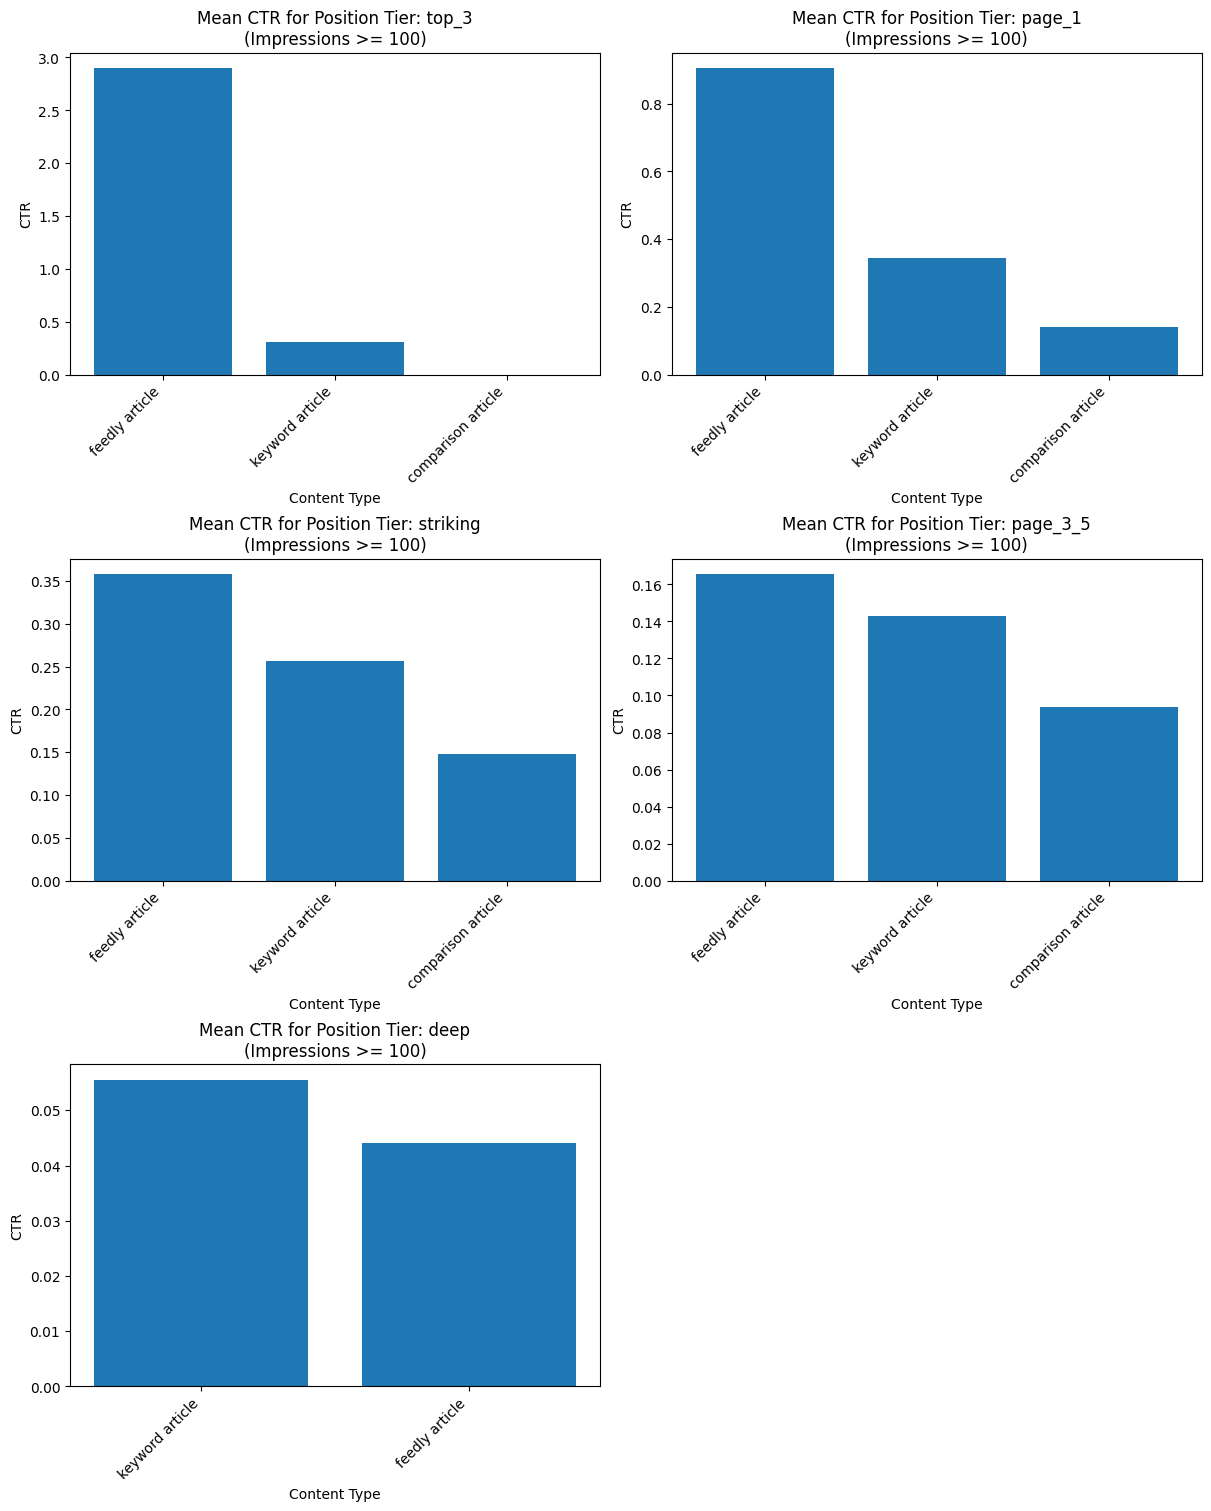

The content type that has the worst CTR for page_1, page_3_5, striking, and top_3 position tier is comparison article.
Meanwhile, feedly article is the worst content type for deep position tier


In [43]:
#Discovery B for the content type that has the worst CTR at the same position tier
import matplotlib.pyplot as plt
import math

visible = df[df["impressions_90d"] >= 100]
ctr_by_PositionTier_and_ContentType = visible.groupby(["position_tier", "content_type"])["ctr"].mean().sort_values(ascending=False).reset_index()

worst_per_tier = ctr_by_PositionTier_and_ContentType.loc[ctr_by_PositionTier_and_ContentType.groupby("position_tier")["ctr"].idxmin()]
print(worst_per_tier)

unique_tiers = ctr_by_PositionTier_and_ContentType["position_tier"].unique()
n = len(unique_tiers)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for i, tier in enumerate(unique_tiers):
    tier_data = ctr_by_PositionTier_and_ContentType[
        ctr_by_PositionTier_and_ContentType["position_tier"] == tier
    ].sort_values(by="ctr", ascending=False)

    ax = axes[i]
    ax.bar(tier_data["content_type"], tier_data["ctr"])
    ax.set_title(f"Mean CTR for Position Tier: {tier}\n(Impressions >= 100)")
    ax.set_ylabel("CTR")
    ax.set_xlabel("Content Type")
    ax.set_xticks(range(len(tier_data)))
    ax.set_xticklabels(tier_data["content_type"], rotation=45, ha="right")


for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.show()

print("The content type that has the worst CTR for page_1, page_3_5, striking, and top_3 position tier is comparison article.")
print("Meanwhile, feedly article is the worst content type for deep position tier")

['down' 'stable' 'new' 'up' 'flat']
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


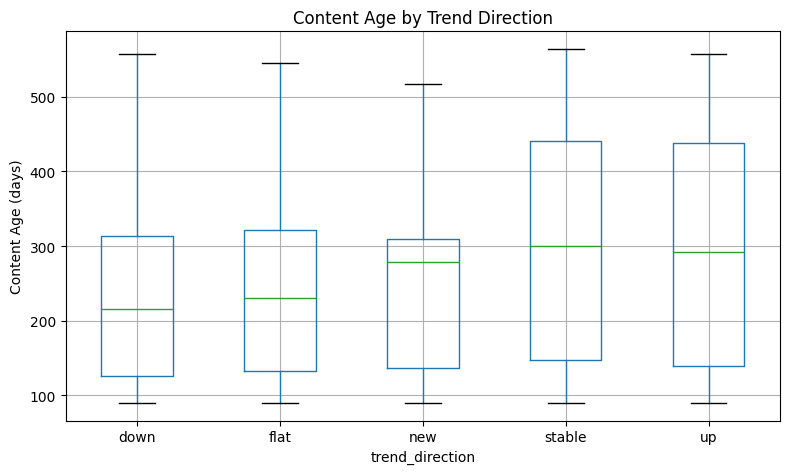

                       mean  median         std  count
trend_direction                                       
down             236.178637   216.0  126.964539  16262
flat             245.889757   231.0  117.499820   1152
new              238.718247   279.0  100.288997   2236
stable           295.439953   300.0  138.999896   5962
up               288.478806   291.5  144.481199   4388
ANOVA F-stat: 311.579, p-value: 0.0000


In [45]:
#Discovery C content age and trend direction

print(df["trend_direction"].unique())
print(df["trend_direction"].value_counts())
# Boxplot: age distribution per trend_direction category
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="content_age_days", by="trend_direction", ax=ax)
ax.set_title("Content Age by Trend Direction")
ax.set_ylabel("Content Age (days)")
plt.suptitle("")  # remove default pandas suptitle
plt.tight_layout()
plt.show()

# Summary stats table
age_by_trend = df.groupby("trend_direction")["content_age_days"].agg(["mean", "median", "std", "count"])
print(age_by_trend)

from scipy import stats

groups = [g["content_age_days"].dropna().values for _, g in df.groupby("trend_direction")]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-stat: {f_stat:.3f}, p-value: {p_value:.4f}")g

Content age shows a statistically significant association with trend_direction (ANOVA p < 0.001) — content in 'stable' and 'up' trend categories skews older in this sample than 'down' or 'flat' categories — though the practical size of this difference should be interpreted cautiously given the large sample size involved.

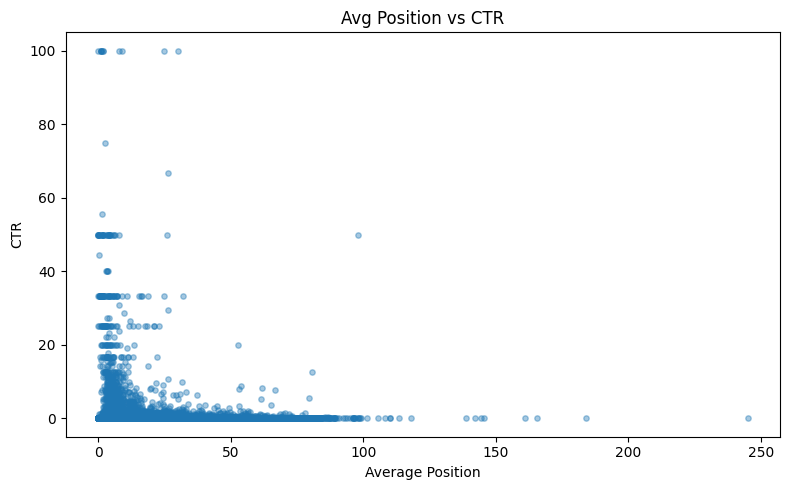

              avg_position       ctr
avg_position      1.000000 -0.144447
ctr              -0.144447  1.000000


In [46]:
#Discovery C avg_position and CTR relation
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["avg_position"], df["ctr"], alpha=0.4, s=15)
ax.set_xlabel("Average Position")
ax.set_ylabel("CTR")
ax.set_title("Avg Position vs CTR")
plt.tight_layout()
plt.show()

corr = df[["avg_position", "ctr"]].corr(method="spearman")
print(corr)

avg_position and CTR show a weak negative association (Spearman ρ ≈ -0.14) in this dataset, consistent with the general pattern of CTR declining at lower positions, though position alone does not appear to be a strong predictor of CTR variance.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.